In [1]:
import numpy as np                     # array math
import pandas as pd                    # tables & dates
import xarray as xr                    # read/handle .nc files (main tool)
import netCDF4                         # .nc reader engine 
import scipy.stats as stats            # stats: distributions, percentiles

import geopandas as gpd                # shapefiles (note: gpd, not pd!)
import rioxarray                       # CRS, clipping, resolution
import regionmask                      # mask by country/region

import matplotlib.pyplot as plt        # make plots
import cartopy.crs as ccrs             # map projections
import cartopy.feature as cfeature     # coastlines, borders
from matplotlib.colors import BoundaryNorm

import metpy.calc as mpcalc            # weather math
from metpy.plots import ContourPlot, ImagePlot, MapPanel, PanelContainer  # quick maps
from metpy.units import units          # attach units (mm, K…)
from datetime import datetime          # dates
import cftime                          # odd climate calendars
import glob
import random


In [2]:
files = sorted(glob.glob("/g/data/zv2/agcd/v2-0-3/precip/total/r005/01month/agcd_v2_precip_total_r005_monthly_*.nc"))
files = [f for f in files if 1939 <= int(f.split("_")[-1][:4]) <= 2023]
#print(files)  # always check you got the right 

print("Number of files:", len(files))

ds = xr.open_mfdataset(files, combine="by_coords") #puting nc file in ds variable
print(ds) #to know name of the precipitation data


Number of files: 85


/jobfs/171551720.gadi-pbs/ipykernel_3023840/2105372635.py:7: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(files, combine="by_coords") #puting nc file in ds variable


<xarray.Dataset> Size: 3GB
Dimensions:    (time: 1020, lat: 691, nv: 2, lon: 886)
Coordinates:
  * time       (time) datetime64[ns] 8kB 1939-01-16 ... 2023-12-16
  * lat        (lat) float32 3kB -44.5 -44.45 -44.4 ... -10.1 -10.05 -10.0
  * lon        (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
Dimensions without coordinates: nv
Data variables:
    lat_bnds   (time, lat, nv) float32 6MB dask.array<chunksize=(12, 691, 2), meta=np.ndarray>
    lon_bnds   (time, lon, nv) float32 7MB dask.array<chunksize=(12, 886, 2), meta=np.ndarray>
    time_bnds  (time, nv) datetime64[ns] 16kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    precip     (time, lat, lon) float32 2GB dask.array<chunksize=(1, 691, 886), meta=np.ndarray>
    crs        (time) int32 4kB -2147483647 -2147483647 ... -2147483647
Attributes: (12/33)
    geospatial_lat_min:        -44.525
    geospatial_lat_max:        -9.975
    geospatial_lon_min:        111.975
    geospatial_lon_max:        156.275
    tim

In [3]:
# Put precipitation values into the variable called rain
rain = ds["precip"]
#print(rain)
# Rechunk the data so the full 1020 month time dimension is in one chunk.
# This allows the 12-month rolling window to see enough months at once.
rain = rain.chunk({"time": -1, "lat": -1, "lon": -1})

# Check the new chunk structure
print(rain.chunks)

# Calculate 12-month moving average at every grid cell
rain_12m = rain.rolling(time=12, min_periods=12).mean()

# Select a small sample for checking
rain_12m_sample = rain_12m.isel(lat=25, lon=25)

# Convert the small gridded sample to a table
rain_12m_table = rain_12m_sample.compute().to_dataframe(name="rain_12m").reset_index()

# Display the table
print(rain_12m_table)

((1020,), (691,), (886,))
                    time    lat     lon    rain_12m
0    1939-01-16 00:00:00 -43.25  113.25         NaN
1    1939-02-14 12:00:00 -43.25  113.25         NaN
2    1939-03-16 00:00:00 -43.25  113.25         NaN
3    1939-04-15 12:00:00 -43.25  113.25         NaN
4    1939-05-16 00:00:00 -43.25  113.25         NaN
...                  ...    ...     ...         ...
1015 2023-08-16 00:00:00 -43.25  113.25  189.399994
1016 2023-09-15 12:00:00 -43.25  113.25  189.399994
1017 2023-10-16 00:00:00 -43.25  113.25  189.399994
1018 2023-11-15 12:00:00 -43.25  113.25  189.399994
1019 2023-12-16 00:00:00 -43.25  113.25  189.399994

[1020 rows x 4 columns]


In [4]:
rain_sample = rain.isel(lat=25, lon=25).compute().to_dataframe(name="raw_precip").reset_index()
print(rain_sample[rain_sample['time'].dt.year == 2023].to_string(index=False))

               time    lat    lon  raw_precip
2023-01-16 00:00:00 -43.25 113.25   23.635742
2023-02-14 12:00:00 -43.25 113.25   10.958008
2023-03-16 00:00:00 -43.25 113.25   66.800781
2023-04-15 12:00:00 -43.25 113.25  136.229492
2023-05-16 00:00:00 -43.25 113.25  298.946289
2023-06-15 12:00:00 -43.25 113.25  397.230469
2023-07-16 00:00:00 -43.25 113.25  425.688477
2023-08-16 00:00:00 -43.25 113.25  361.944336
2023-09-15 12:00:00 -43.25 113.25  255.532227
2023-10-16 00:00:00 -43.25 113.25  159.197266
2023-11-15 12:00:00 -43.25 113.25   99.888672
2023-12-16 00:00:00 -43.25 113.25   36.748047


In [5]:
one_cell_raw = rain.sel(lat=-40.0, lon=148.0, method="nearest")
one_cell_12m = rain_12m.sel(lat=-40.0, lon=148.0, method="nearest")

one_cell_check = pd.DataFrame({
    "raw_monthly_rainfall": one_cell_raw.compute().to_series(),
    "rain_12m_moving_average": one_cell_12m.compute().to_series()
})

print(one_cell_check.loc["1945"]) #Checking monthly and moving average for 1941

# Calculate the 25th percentile of the 12-month moving average values.
# We use dropna() because the first 11 months are NaN.
p25_one_grid_1945_only = one_cell_check.loc["1945", "rain_12m_moving_average"].dropna().quantile(0.25)
p25_one_grid = one_cell_check["rain_12m_moving_average"].dropna().quantile(0.25)

print("25th percentile threshold (1 year check):", p25_one_grid_1945_only) # This is 25th percentile using 1945 data only
print("25th percentile threshold:", p25_one_grid)

                     raw_monthly_rainfall  rain_12m_moving_average
time                                                              
1945-01-16 00:00:00             42.712891                49.602459
1945-02-14 12:00:00            116.289062                58.405437
1945-03-16 00:00:00             28.881836                57.280113
1945-04-15 12:00:00             28.739258                53.873535
1945-05-16 00:00:00             46.334961                48.607830
1945-06-15 12:00:00             50.209961                49.677979
1945-07-16 00:00:00             28.991211                47.513592
1945-08-16 00:00:00            109.159180                53.306969
1945-09-15 12:00:00             54.852539                55.101562
1945-10-16 00:00:00             71.006836                58.625244
1945-11-15 12:00:00             33.291992                58.013592
1945-12-16 00:00:00              7.117188                51.465576
25th percentile threshold (1 year check): 49.659098625183105
2

In [6]:
#Calculate 25th percentile for every grid cell
p25 = rain_12m.quantile(0.25, dim="time", skipna=True)
print(p25)

<xarray.DataArray 'precip' (lat: 691, lon: 886)> Size: 5MB
dask.array<getitem, shape=(691, 886), dtype=float64, chunksize=(691, 886), chunktype=numpy.ndarray>
Coordinates:
  * lat       (lat) float32 3kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon       (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
    quantile  float64 8B 0.25
Attributes:
    cell_methods:           time: sum time: sum (interval : 1 day)
    units:                  mm
    long_name:              Daily precipitation
    standard_name:          lwe_thickness_of_precipitation_amount
    frequency:              monthly
    start_offset:           -24
    grid_mapping:           crs
    coverage_content_type:  physicalMeasurement
    valid_range:            [     0. 100000.]


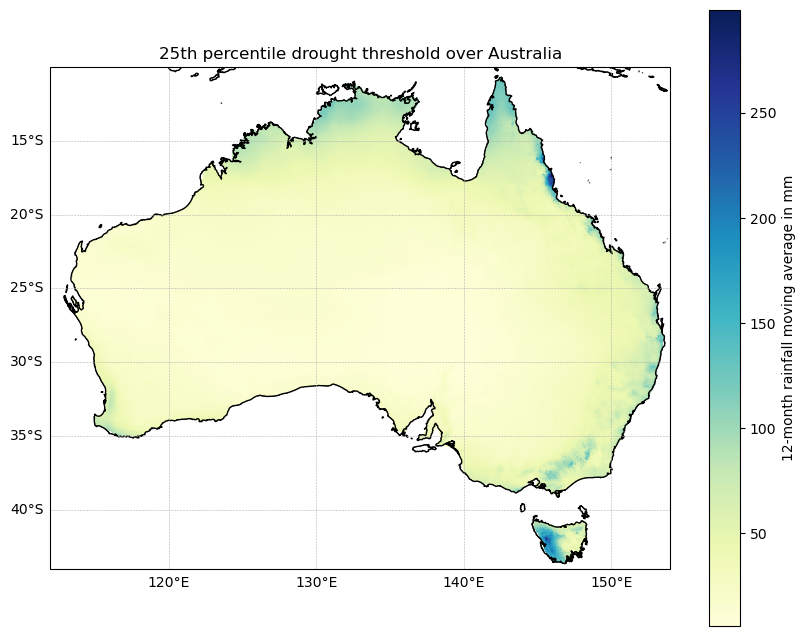

In [7]:
#Plot of the 25th Percentile value 
p25 = p25.squeeze(drop=True)

# Mask to Australia only
mask = regionmask.defined_regions.natural_earth_v5_0_0.countries_110.mask(p25.lon, p25.lat)
p25_masked = p25.where(mask == 137)  # 137 is Australia's index

# Create map figure using PlateCarree projection.
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the 25th percentile rainfall threshold
p25_masked.plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap="YlGnBu",
    cbar_kwargs={"label": "12-month rainfall moving average in mm"}
)
# Add Australian coastline
ax.coastlines(resolution="10m", linewidth=1.0, color="black")
# Add country borders
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="black")
# Add land outline lightly
ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.5)
# Zoom to Australia
ax.set_extent([112, 154, -44, -10], crs=ccrs.PlateCarree())
# Add longitude/latitude gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle="--")
gl.top_labels = False
gl.right_labels = False
ax.set_title("25th percentile drought threshold over Australia")
plt.show()

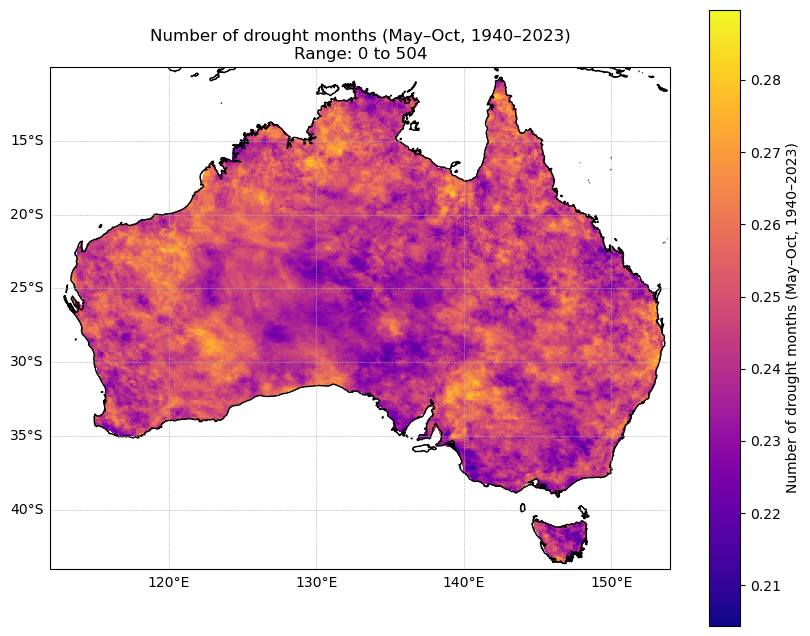

Total possible months per grid: 504
Max drought count any grid:     146
Min drought count any grid:     0


In [8]:
# Select May–Oct across ALL years (1940–2023)
rain_12m_may_oct = rain_12m.sel(time=rain_12m.time.dt.month.isin([5, 6, 7, 8, 9, 10]))
rain_12m_may_oct = rain_12m_may_oct.sel(time=slice("1940", "2023"))

# Defining drought
drought_may_oct = rain_12m_may_oct < p25

# Count drought months per grid cell (0 to 504)
drought_count = drought_may_oct.sum(dim="time", skipna=True)

#Normalise 0-1
drought_count_norm = drought_count/ 504

# Mask to Australia
mask = regionmask.defined_regions.natural_earth_v5_0_0.countries_110.mask(drought_count.lon, drought_count.lat)
drought_count_masked = drought_count_norm.where(mask == 137)

# Plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

drought_count_masked.plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap="plasma",
    cbar_kwargs={"label": "Number of drought months (May–Oct, 1940–2023)"}
)

ax.coastlines(resolution="10m", linewidth=1.0, color="black")
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="black")
ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.5)
ax.set_extent([112, 154, -44, -10], crs=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle="--")
gl.top_labels = False
gl.right_labels = False

ax.set_title("Number of drought months (May–Oct, 1940–2023)\nRange: 0 to 504")
plt.show()

# Sanity check
print(f"Total possible months per grid: {len(rain_12m_may_oct.time)}")
print(f"Max drought count any grid:     {int(drought_count.max().values)}")
print(f"Min drought count any grid:     {int(drought_count.min().values)}")

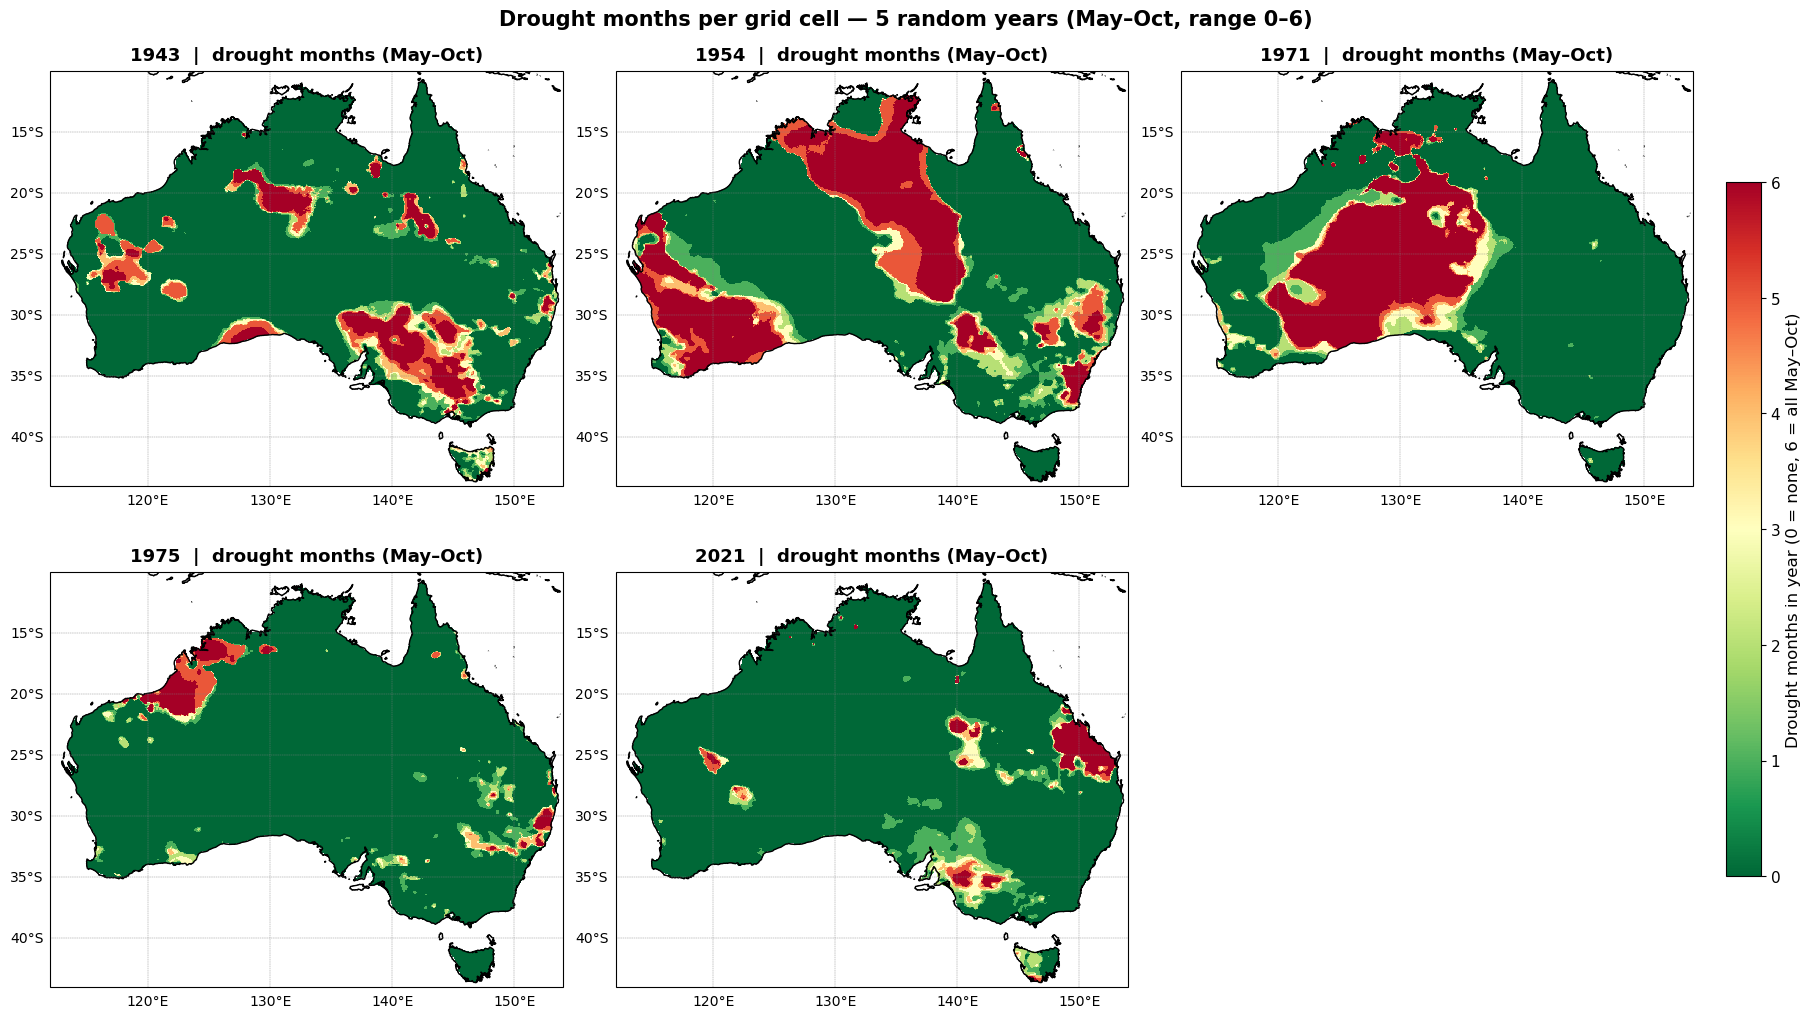

Year        Max    Min
----------------------
1943          6      0
1954          6      0
1971          6      0
1975          6      0
2021          6      0


In [9]:
import random
# Pick 5 random years from 1940–2023
random.seed(42)
years = random.sample(range(1940, 2024), 5)
years.sort()
fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)
axes = axes.flatten()
for idx, year in enumerate(years):
    ax = axes[idx]
    # Select May–Oct for this single year only
    rain_year = rain_12m.sel(time=rain_12m.time.dt.year == year)
    rain_year = rain_year.sel(time=rain_year.time.dt.month.isin([5, 6, 7, 8, 9, 10]))  # ← CHANGED rain_12m to rain_year
    # Drought: 1 if < p25, else 0
    drought_year = rain_year < p25
    # Count drought months per grid cell (0 to 6)
    drought_count_year = drought_year.sum(dim="time", skipna=True)
    # Mask to Australia
    mask = regionmask.defined_regions.natural_earth_v5_0_0.countries_110.mask(
        drought_count_year.lon, drought_count_year.lat
    )
    drought_count_masked = drought_count_year.where(mask == 137)
    # Plot
    p = drought_count_masked.plot(
        ax=ax,
        x="lon",
        y="lat",
        transform=ccrs.PlateCarree(),
        cmap="RdYlGn_r",
        vmin=0,
        vmax=6,
        add_colorbar=False,
    )
    ax.coastlines(resolution="10m", linewidth=1.0, color="black")
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="black")
    ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.5)
    ax.set_extent([112, 154, -44, -10], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", color="gray")
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(f"{year}  |  drought months (May–Oct)", fontsize=13, fontweight="bold", pad=8)
# Hide the 6th subplot (we only have 5 years)
axes[5].set_visible(False)
# Single shared colorbar
cbar = fig.colorbar(
    p,
    ax=axes[:5],
    orientation="vertical",
    shrink=0.7,
    pad=0.02,
    ticks=[0, 1, 2, 3, 4, 5, 6]
)
cbar.set_label("Drought months in year (0 = none, 6 = all May–Oct)", fontsize=12)
cbar.ax.tick_params(labelsize=11)
fig.suptitle(
    "Drought months per grid cell — 5 random years (May–Oct, range 0–6)",
    fontsize=15,
    fontweight="bold",
    y=1.02
)
plt.show()
# Sanity check for each year
print(f"{'Year':<8} {'Max':>6} {'Min':>6}")
print("-" * 22)
for year in years:
    rain_year = rain_12m.sel(time=rain_12m.time.dt.year == year)
    rain_year = rain_year.sel(time=rain_year.time.dt.month.isin([5, 6, 7, 8, 9, 10]))  # ← CHANGED rain_12m to rain_year
    dc = (rain_year < p25).sum(dim="time", skipna=True)
    print(f"{year:<8} {int(dc.max().values):>6} {int(dc.min().values):>6}")

In [11]:
from pathlib import Path

# ── Output folder ─────────────────────────────────────────────────────────────
output_dir = Path("/g/data/nf33/sg3790/Hydrologic_drought_netcdf")
output_dir.mkdir(parents=True, exist_ok=True)

# ── Loop over each year ───────────────────────────────────────────────────────
years_all = range(1940, 2024)
drought_yearly_list = []

for year in years_all:
    print(f"Processing {year}...", end="\r")
    rain_year = rain_12m.sel(time=rain_12m.time.dt.year == year)
    rain_year = rain_year.sel(time=rain_year.time.dt.month.isin([5, 6, 7, 8, 9, 10]))
    drought_year = (rain_year < p25)
    drought_count_year = drought_year.sum(dim="time", skipna=True)
    drought_norm_year = drought_count_year / 6.0
    drought_norm_year = drought_norm_year.expand_dims(year=[year])
    drought_yearly_list.append(drought_norm_year)

print("All years processed")

drought_all = xr.concat(drought_yearly_list, dim="year")

ds = xr.Dataset(
    {"drought_fraction": drought_all},
    attrs={
        "description":   "Normalised cool-season drought fraction per grid cell per year",
        "months":        "May to October",
        "years":         "1940 to 2023",
        "normalisation": "drought_count (0–6) / 6.0  →  0 = no drought months, 1 = all 6 months in drought",
        "threshold":     "p25 of 12-month rolling rainfall",
    }
)

ds["drought_fraction"].attrs = {
    "long_name": "Drought fraction (cool season)",
    "units":     "1",
    "valid_min": 0.0,
    "valid_max": 1.0,
}

output_path = output_dir / "drought_fraction_may_oct_1940_2023.nc"
ds.to_netcdf(output_path)
print(f"Saved to: {output_path}")

print(f"\nDataset shape:  {drought_all.dims}  →  {dict(drought_all.sizes)}")
print(f"Max value:      {float(drought_all.max().values):.3f}  (should be ≤ 1.0)")
print(f"Min value:      {float(drought_all.min().values):.3f}  (should be ≥ 0.0)")
print(f"Years in file:  {int(drought_all.year.min())} to {int(drought_all.year.max())}")

All years processed.          
Saved to: /g/data/nf33/sg3790/Hydrologic_drought_netcdf/drought_fraction_may_oct_1940_2023.nc

Dataset shape:  ('year', 'lat', 'lon')  →  {'year': 84, 'lat': 691, 'lon': 886}
Max value:      1.000  (should be ≤ 1.0)
Min value:      0.000  (should be ≥ 0.0)
Years in file:  1940 to 2023


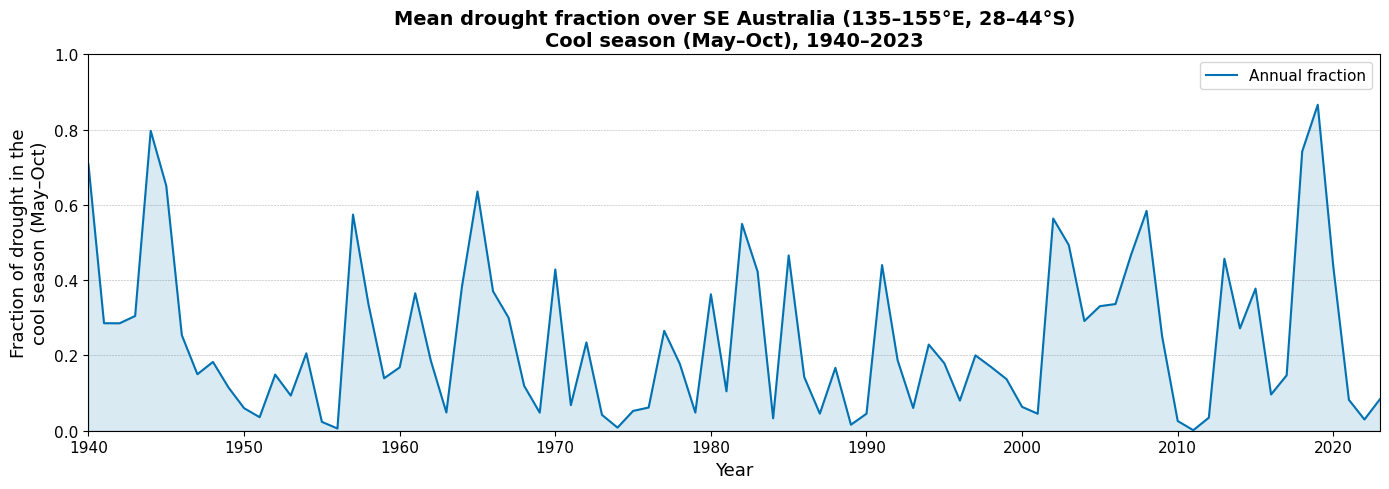

Max fraction any year:  0.866  (2019)
Min fraction any year:  0.001  (2011)
Long-term mean:         0.244


In [13]:
# ── Time series 1940–2023
lat_min, lat_max = -45, -28
lon_min, lon_max = 130, 155

# Load the already-computed NetCDF
ds = xr.open_dataset("/g/data/nf33/sg3790/Hydrologic_drought_netcdf/drought_fraction_may_oct_1940_2023.nc")

# Apply Australia land mask
mask = regionmask.defined_regions.natural_earth_v5_0_0.countries_110.mask(
    ds["drought_fraction"].lon, ds["drought_fraction"].lat
)
drought_masked = ds["drought_fraction"].where(mask == 137)

# Clip to SE Australia boundary
drought_region = drought_masked.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

# Spatial mean per year — no loop needed, xarray does all 84 years at once
drought_fraction = drought_region.mean(dim=["lat", "lon"], skipna=True).values
years_arr = ds["drought_fraction"].year.values

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(years_arr, drought_fraction, color="#0072B2", linewidth=1.5, zorder=2, label="Annual fraction")
ax.fill_between(years_arr, drought_fraction, alpha=0.15, color="#0072B2")

ax.set_xlim(1940, 2023)
ax.set_ylim(0, 1)
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Fraction of drought in the\ncool season (May–Oct)", fontsize=13)
ax.set_title(
    "Mean drought fraction over SE Australia (135–155°E, 28–44°S)\nCool season (May–Oct), 1940–2023",
    fontsize=14, fontweight="bold"
)
ax.legend(fontsize=11)
ax.grid(axis="y", linewidth=0.4, linestyle="--", color="gray", alpha=0.6)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f"Max fraction any year:  {drought_fraction.max():.3f}  ({years_arr[drought_fraction.argmax()]})")
print(f"Min fraction any year:  {drought_fraction.min():.3f}  ({years_arr[drought_fraction.argmin()]})")
print(f"Long-term mean:         {mean_val:.3f}")

In [37]:
xr.DataArray(drought_fraction)

<xarray.DataArray (dim_0: 84)> Size: 672B
array([0.70734853, 0.2856585 , 0.28544735, 0.30485512, 0.79680412,
       0.65068272, 0.25388133, 0.15006289, 0.18280727, 0.11489367,
       0.05996249, 0.03593436, 0.14908433, 0.09339482, 0.20557985,
       0.0236081 , 0.00588046, 0.57424814, 0.33472739, 0.13935547,
       0.16833999, 0.36525354, 0.18642409, 0.04851944, 0.38238406,
       0.6354889 , 0.37054141, 0.30012805, 0.11930515, 0.04799043,
       0.42847866, 0.06789543, 0.23460297, 0.04217354, 0.00820539,
       0.05259489, 0.06164943, 0.26542655, 0.17801209, 0.04828786,
       0.36249495, 0.10475613, 0.54954795, 0.42309317, 0.0329964 ,
       0.46580708, 0.14256815, 0.04549294, 0.16710032, 0.01598621,
       0.04524092, 0.44010562, 0.18718696, 0.06043702, 0.22891096,
       0.17933576, 0.08005821, 0.20021251, 0.169591  , 0.13702599,
       0.06339314, 0.04514102, 0.56377457, 0.49329083, 0.29148673,
       0.33091531, 0.33660732, 0.46699679, 0.58406101, 0.25006244,
       0.02584903, 0.00137589, 0.03468561, 0.45690693, 0.2720449 ,
       0.37756844, 0.09630099, 0.14719986, 0.74213177, 0.8660323 ,
       0.4352287 , 0.08214248, 0.02988362, 0.08399063])
Dimensions without coordinates: dim_0

Data range: 0.2000 to 0.3000
Figure saved.


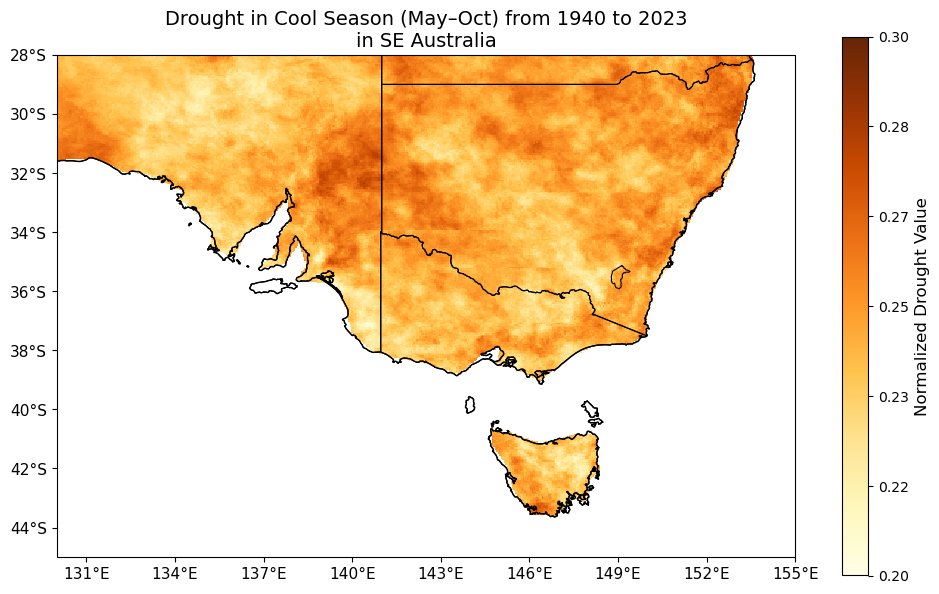

Max mean fraction: 0.284
Min mean fraction: 0.204
Overall mean:      0.244


In [49]:
import cartopy.io.shapereader as shpreader
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as mticker

# ── Load NetCDF ───────────────────────────────────────────────────────────────
ds = xr.open_dataset("/g/data/nf33/sg3790/Hydrologic_drought_netcdf/drought_fraction_may_oct_1940_2023.nc")

# ── Mean drought fraction across all years (1940–2023) per grid cell ──────────
drought_mean = ds["drought_fraction"].mean(dim="year", skipna=True)

# ── Australia land mask ───────────────────────────────────────────────────────
mask = regionmask.defined_regions.natural_earth_v5_0_0.countries_110.mask(
    drought_mean.lon, drought_mean.lat
)
drought_mean_masked = drought_mean.where(mask == 137)

# ── Clip to spatial boundary ──────────────────────────────────────────────────
lat_min, lat_max = -45, -28
lon_min, lon_max = 130, 155
drought_mean_region = drought_mean_masked.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

# ── Use actual data range for vmin/vmax so colors show real variance ──────────
vmin = 0.2
vmax = 0.3
print(f"Data range: {vmin:.4f} to {vmax:.4f}")

# ── Build colorbar ticks from actual data range ───────────────────────────────
cbar_ticks = np.linspace(vmin, vmax, 7)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

p = drought_mean_region.plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap="YlOrBr",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False                  # ← we draw colorbar manually
)

# ── Manual colorbar with actual data value labels ────────────────────────────
cbar = fig.colorbar(p, ax=ax, shrink=0.7, ticks=cbar_ticks)
cbar.set_label("Normalized Drought Value", fontsize=12)
cbar.ax.set_yticklabels([f"{t:.2f}" for t in cbar_ticks], fontsize=10)  # ← actual values beside bar

# ── Australian state boundaries ───────────────────────────────────────────────
states_shp = shpreader.natural_earth(
    resolution='10m',
    category='cultural',
    name='admin_1_states_provinces'
)
reader = shpreader.Reader(states_shp)
for rec in reader.records():
    if rec.attributes['admin'] == 'Australia':
        geom = rec.geometry
        if geom.geom_type == 'Polygon':
            x, y = geom.exterior.xy
            ax.plot(x, y, 'k-', linewidth=0.8)
        elif geom.geom_type == 'MultiPolygon':
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                ax.plot(x, y, 'k-', linewidth=0.8)

ax.coastlines(resolution="10m", linewidth=1.0, color="black")
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# ── Ticks only, no grid ───────────────────────────────────────────────────────
ax.set_xticks(np.arange(131, 156, 3), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-44, -27, 2), crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.tick_params(axis="both", labelsize=11)

ax.set_title(
    "Drought in Cool Season (May–Oct) from 1940 to 2023\nin SE Australia",
    fontsize=14, fontweight="normal"
)
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

# ── Save figure ───────────────────────────────────────────────────────────────
fig.savefig(
    "/home/561/sg3790/colloqium_project/GC26-wind-hydro-droughts/analysis/figures/drought_mean_may_oct_1940_2023.png",
    dpi=300, bbox_inches="tight"
)
print("Figure saved.")

plt.show()

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f"Max mean fraction: {float(drought_mean_region.max().values):.3f}")
print(f"Min mean fraction: {float(drought_mean_region.min().values):.3f}")
print(f"Overall mean:      {float(drought_mean_region.mean().values):.3f}")